<a href="https://colab.research.google.com/github/nixos18/Projet-N1-Pr-diction-du-prix-d-achat-optimal-des-mati-res-premi-res-industrielles-regression-/blob/main/MatieresPremi%C3%A8res_MAD_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Prédiction du Prix d'Achat Optimal des Matières Premières Industrielles
## Dataset MAD/tonne — Maroc 2020–2024 | 600 transactions

> **Objectif** : Construire un pipeline ML complet pour prédire le `Prix_Achat_Optimal_MAD_t` (régression supervisée) à partir de 35 variables couvrant l'identification de la transaction, la matière première, le fournisseur, les prix/change et les composantes TCO.

---
**Plan du notebook :**
1. Installation & imports
2. Chargement des données
3. Exploration (EDA)
4. Visualisations
5. Prétraitement & feature engineering
6. Modélisation ML
7. Évaluation & interprétabilité
8. Export des résultats


## ⚙️ 1. Installation & Imports

In [4]:
# Installer les librairies supplémentaires si besoin
!pip install -q shap xgboost lightgbm openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

# Interprétabilité
import shap

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
SEED = 42

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


## 📥 2. Chargement des Données

In [7]:
# ── Option A : Upload depuis votre ordinateur ──────────────────────────────
from google.colab import files
uploaded = files.upload()  # Sélectionnez 'Dataset_MatieresPremières_MAD_Optimisation.xlsx'
FILENAME = list(uploaded.keys())[0]

# ── Option B : Depuis Google Drive (décommenter) ───────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# FILENAME = '/content/drive/MyDrive/Dataset_MatieresPremières_MAD_Optimisation.xlsx'

Saving Dataset_MatieresPremières_MAD_Optimisation.xlsx to Dataset_MatieresPremières_MAD_Optimisation.xlsx


In [13]:
# Lecture de la feuille principale
raw = pd.read_excel(FILENAME, sheet_name='📊 Dataset', header=1)
df = raw.copy()

# Renommer les colonnes (noms propres sans espaces)
df.columns = [
    'ID_Transaction', 'Date_Achat', 'Annee', 'Mois', 'Trimestre', 'Saison',
    'Region', 'Matiere_Premiere', 'Unite_Mesure', 'Secteur_Industriel',
    'Volume_Commande_t', 'Volatilite_Marche_Pct', 'Fournisseur_Origine',
    'Incoterm', 'Mode_Paiement', 'Certification_Fournisseur',
    'Delai_Livraison_j', 'Fiabilite_Fournisseur', 'Risque_Qualite',
    'Score_Fournisseur', 'Prix_Mondial_USD_t', 'Taux_Change_MAD_USD',
    'Prix_Brut_MAD_t', 'Remise_Volume_Pct', 'Prix_Apres_Remise_MAD',
    'Cout_Transport_MAD_t', 'Cout_Stockage_MAD_t', 'Cout_Risque_Qualite_MAD_t',
    'Cout_Financement_MAD_t', 'Cout_Douane_Taxes_MAD_t', 'TCO_Total_MAD_t',
    'IPI', 'Fenetre_Opportunite', 'Couverture_Prix_Pct',
    'Strategie_Achat', 'Prix_Achat_Optimal_MAD_t'
]

# Typage
df['Date_Achat'] = pd.to_datetime(df['Date_Achat'], errors='coerce')
num_cols = [
    'Annee','Mois','Volume_Commande_t','Volatilite_Marche_Pct',
    'Delai_Livraison_j','Fiabilite_Fournisseur','Risque_Qualite',
    'Score_Fournisseur','Prix_Mondial_USD_t','Taux_Change_MAD_USD',
    'Prix_Brut_MAD_t','Remise_Volume_Pct','Prix_Apres_Remise_MAD',
    'Cout_Transport_MAD_t','Cout_Stockage_MAD_t','Cout_Risque_Qualite_MAD_t',
    'Cout_Financement_MAD_t','Cout_Douane_Taxes_MAD_t','TCO_Total_MAD_t',
    'IPI','Couverture_Prix_Pct','Prix_Achat_Optimal_MAD_t'
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

✅ Dataset chargé : 601 lignes × 36 colonnes


,ID_Transaction,Date_Achat,Annee,Mois,Trimestre,Saison,Region,Matiere_Premiere,Unite_Mesure,Secteur_Industriel,...,Cout_Stockage_MAD_t,Cout_Risque_Qualite_MAD_t,Cout_Financement_MAD_t,Cout_Douane_Taxes_MAD_t,TCO_Total_MAD_t,IPI,Fenetre_Opportunite,Couverture_Prix_Pct,Strategie_Achat,Prix_Achat_Optimal_MAD_t
0,ID Transaction,NaT,NaN,NaN,Trimestre,Saison,Region Acheteur Maroc,Matiere Premiere,Unite Mesure,Secteur Industriel,...,NaN,NaN,NaN,NaN,NaN,NaN,Fenetre Opportunite,NaN,Strategie Achat,NaN
1,TXN-0001,2023-08-02,2023.0,8.0,Q3,Été,Souss-Massa,Aluminium,Tonne,BTP,...,6.18,643.68,25.75,205.98,26139.92,1.175,Défavorable,52.3,Report achat / contrat-cadre,25202.44
2,TXN-0002,2020-03-02,2020.0,3.0,Q1,Printemps,Rabat-Salé,Aluminium,Tonne,Emballage,...,29.25,365.67,73.13,609.44,24714.26,0.733,Défavorable,36.9,Report achat / contrat-cadre,23905.65
3,TXN-0003,2020-01-14,2020.0,1.0,Q1,Hiver,Marrakech-Safi,Cuivre,Tonne,BTP,...,58.61,563.54,150.28,601.11,74879.42,-0.016,Neutre,16.6,Achat spot standard,68752.55
4,TXN-0004,2020-03-29,2020.0,3.0,Q1,Printemps,Fès-Meknès,Acide sulfurique,Tonne,Chimie,...,2.26,31.43,7.86,25.14,3062.76,1.168,Défavorable,48.9,Report achat / contrat-cadre,3004.07


## 🔍 3. Exploration des Données (EDA)

In [15]:
print('=' * 65)
print('📊 APERÇU GÉNÉRAL')
print('=' * 65)
print(df.info())
print('\n📈 STATISTIQUES DESCRIPTIVES (variables numériques):')
df[num_cols].describe().T.style.background_gradient(cmap='Blues')

📊 APERÇU GÉNÉRAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID_Transaction             601 non-null    object        
 1   Date_Achat                 600 non-null    datetime64[ns]
 2   Annee                      600 non-null    float64       
 3   Mois                       600 non-null    float64       
 4   Trimestre                  601 non-null    object        
 5   Saison                     601 non-null    object        
 6   Region                     601 non-null    object        
 7   Matiere_Premiere           601 non-null    object        
 8   Unite_Mesure               601 non-null    object        
 9   Secteur_Industriel         601 non-null    object        
 10  Volume_Commande_t          600 non-null    float64       
 11  Volatilite_Marche_Pct      600 non-null    float64    

,count,mean,std,min,25%,50%,75%,max
Annee,600.000000,2021.821667,1.316340,2020.000000,2021.000000,2022.000000,2023.000000,2024.000000
Mois,600.000000,6.210000,3.420829,1.000000,3.000000,6.000000,9.000000,12.000000
Volume_Commande_t,600.000000,119.713833,154.476240,4.300000,15.000000,27.800000,198.325000,574.600000
Volatilite_Marche_Pct,600.000000,15.215000,4.232253,8.000000,12.000000,15.000000,18.000000,22.000000
Delai_Livraison_j,600.000000,21.511667,13.022513,2.000000,13.000000,18.000000,25.000000,51.000000
Fiabilite_Fournisseur,600.000000,0.927933,0.041617,0.860000,0.910000,0.920000,0.960000,0.980000
Risque_Qualite,600.000000,0.029875,0.015002,0.010000,0.020000,0.030000,0.045000,0.050000
Score_Fournisseur,600.000000,0.879171,0.069287,0.744800,0.870200,0.926000,0.927000,0.933800
Prix_Mondial_USD_t,600.000000,2370.426150,2349.530504,108.100000,784.865000,1878.805000,3162.620000,10640.210000
Taux_Change_MAD_USD,600.000000,10.055115,0.181730,9.528700,9.927925,10.057350,10.175500,10.743500


In [16]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print('✅ Aucune valeur manquante détectée !')
else:
    print('⚠️ Valeurs manquantes détectées :')
    print(missing)

⚠️ Valeurs manquantes détectées :
Date_Achat                   1
Annee                        1
Mois                         1
Volume_Commande_t            1
Volatilite_Marche_Pct        1
Delai_Livraison_j            1
Fiabilite_Fournisseur        1
Risque_Qualite               1
Score_Fournisseur            1
Prix_Mondial_USD_t           1
Taux_Change_MAD_USD          1
Prix_Brut_MAD_t              1
Remise_Volume_Pct            1
Prix_Apres_Remise_MAD        1
Cout_Transport_MAD_t         1
Cout_Stockage_MAD_t          1
Cout_Risque_Qualite_MAD_t    1
Cout_Financement_MAD_t       1
Cout_Douane_Taxes_MAD_t      1
TCO_Total_MAD_t              1
IPI                          1
Couverture_Prix_Pct          1
Prix_Achat_Optimal_MAD_t     1
dtype: int64


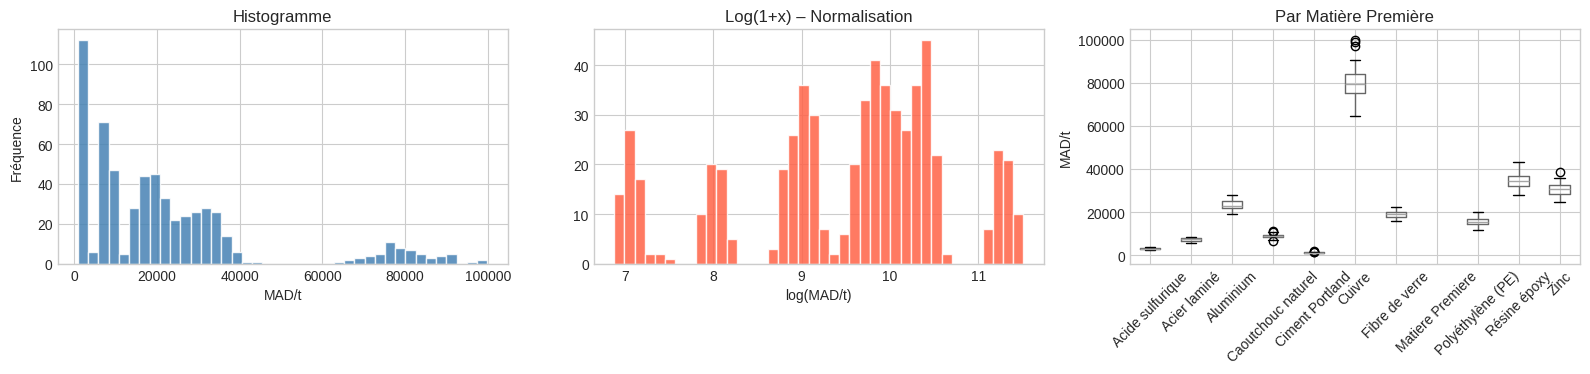

In [17]:
# Distribution de la variable cible
TARGET = 'Prix_Achat_Optimal_MAD_t'

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribution du Prix Achat Optimal (MAD/t)', fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(df[TARGET].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogramme')
axes[0].set_xlabel('MAD/t')
axes[0].set_ylabel('Fréquence')

# Log-transform
axes[1].hist(np.log1p(df[TARGET].dropna()), bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(1+x) – Normalisation')
axes[1].set_xlabel('log(MAD/t)')

# Boxplot par matière
df.boxplot(column=TARGET, by='Matiere_Premiere', ax=axes[2], rot=45)
axes[2].set_title('Par Matière Première')
axes[2].set_xlabel('')
axes[2].set_ylabel('MAD/t')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 📊 4. Visualisations Analytiques

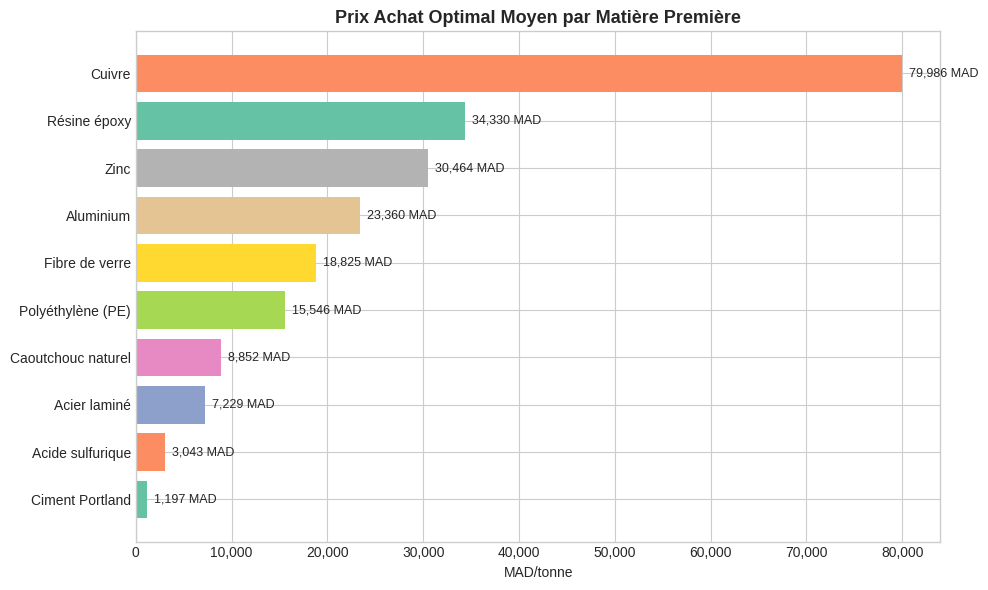

In [18]:
# ── 4.1 Prix moyen optimal par matière première ───────────────────────────
mat_prix = (df.groupby('Matiere_Premiere')[TARGET]
              .mean()
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(mat_prix.index, mat_prix.values,
               color=sns.color_palette('Set2', len(mat_prix)))
ax.bar_label(bars, fmt=lambda x: f'{x:,.0f} MAD', padding=5, fontsize=9)
ax.set_title('Prix Achat Optimal Moyen par Matière Première', fontsize=13, fontweight='bold')
ax.set_xlabel('MAD/tonne')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

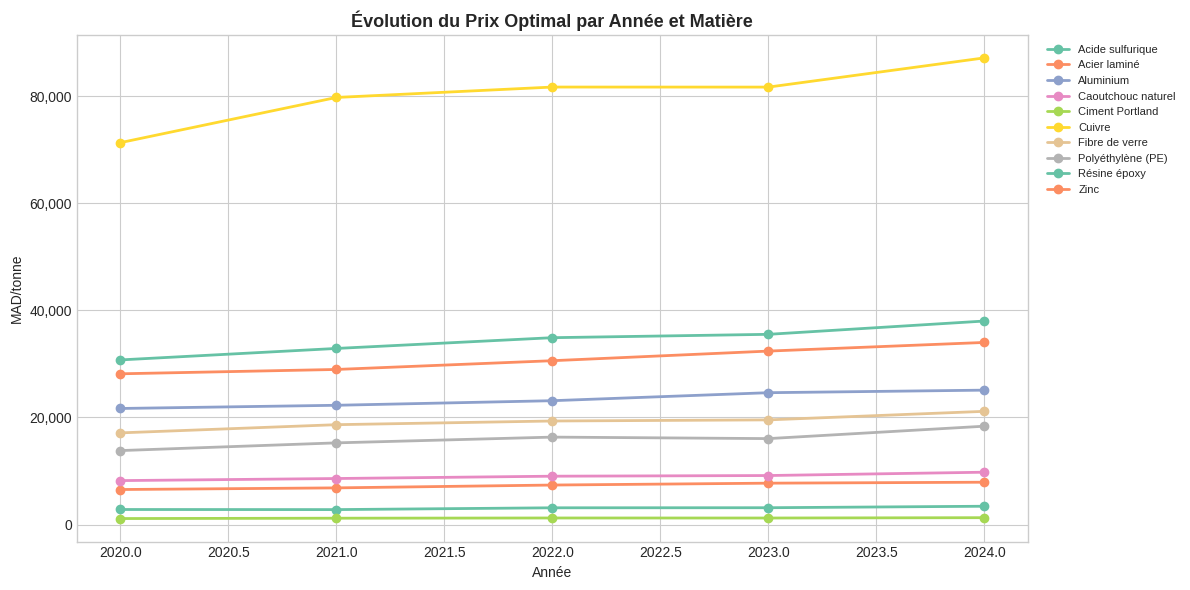

In [19]:
# ── 4.2 Évolution temporelle du prix par année ────────────────────────────
prix_annuel = df.groupby(['Annee', 'Matiere_Premiere'])[TARGET].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
prix_annuel.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Évolution du Prix Optimal par Année et Matière', fontsize=13, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('MAD/tonne')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

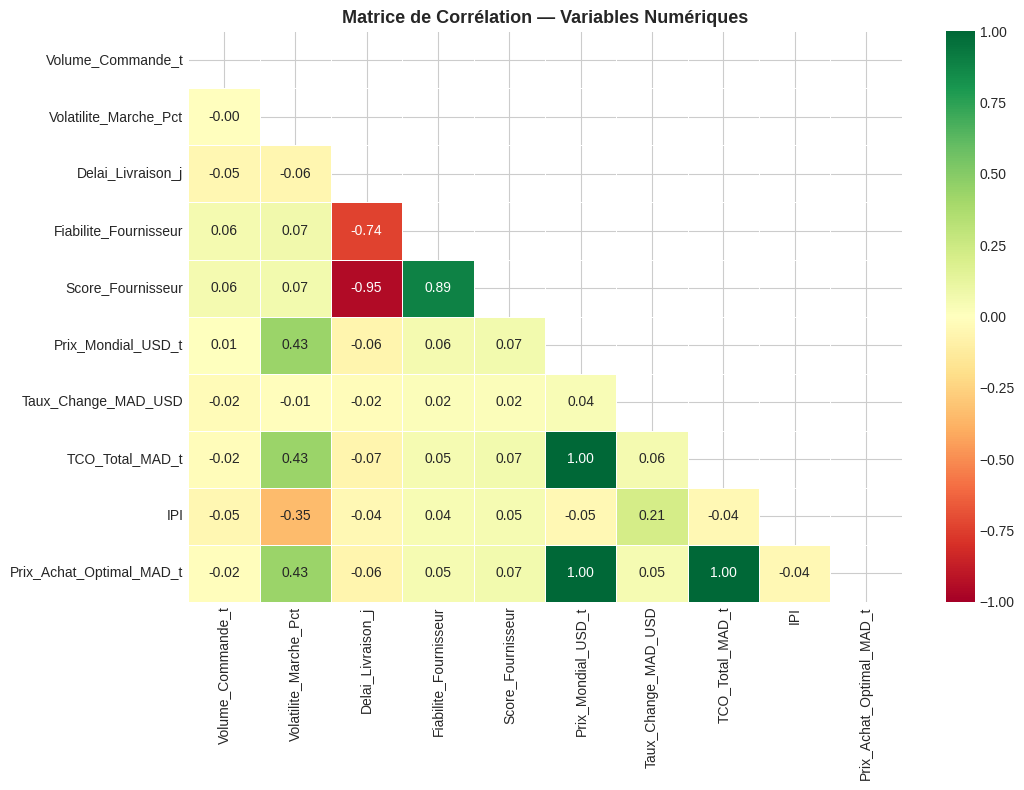

In [20]:
# ── 4.3 Heatmap des corrélations numériques ───────────────────────────────
corr_cols = [
    'Volume_Commande_t', 'Volatilite_Marche_Pct', 'Delai_Livraison_j',
    'Fiabilite_Fournisseur', 'Score_Fournisseur', 'Prix_Mondial_USD_t',
    'Taux_Change_MAD_USD', 'TCO_Total_MAD_t', 'IPI', TARGET
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

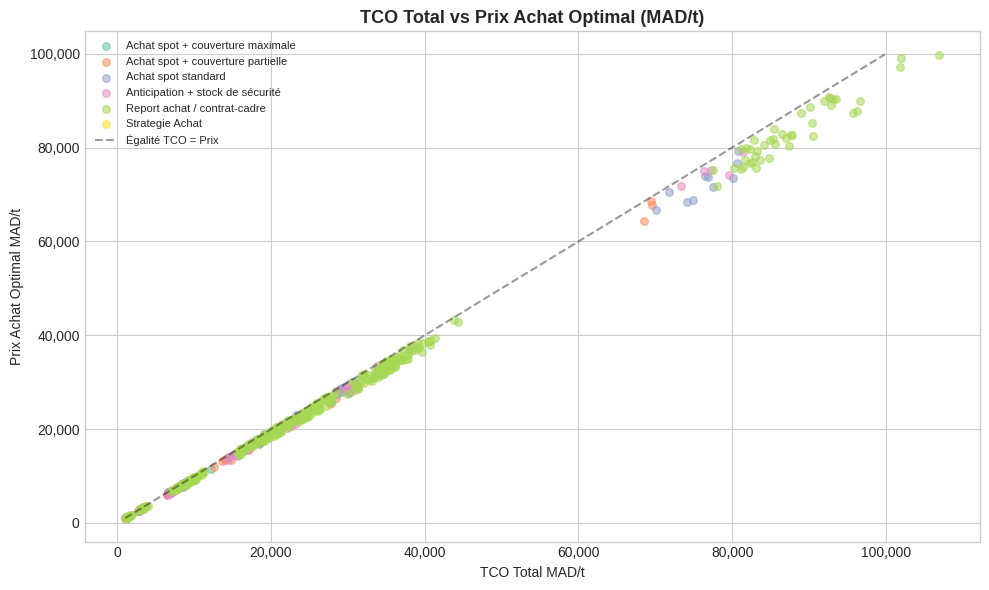

In [21]:
# ── 4.4 TCO vs Prix Optimal — scatter par stratégie ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for strat, grp in df.groupby('Strategie_Achat'):
    ax.scatter(grp['TCO_Total_MAD_t'], grp[TARGET],
               label=strat, alpha=0.55, s=30)

# Ligne diagonale parfaite
lims = [max(df['TCO_Total_MAD_t'].min(), df[TARGET].min()),
        min(df['TCO_Total_MAD_t'].max(), df[TARGET].max())]
ax.plot(lims, lims, 'k--', alpha=0.4, label='Égalité TCO = Prix')

ax.set_title('TCO Total vs Prix Achat Optimal (MAD/t)', fontsize=13, fontweight='bold')
ax.set_xlabel('TCO Total MAD/t')
ax.set_ylabel('Prix Achat Optimal MAD/t')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

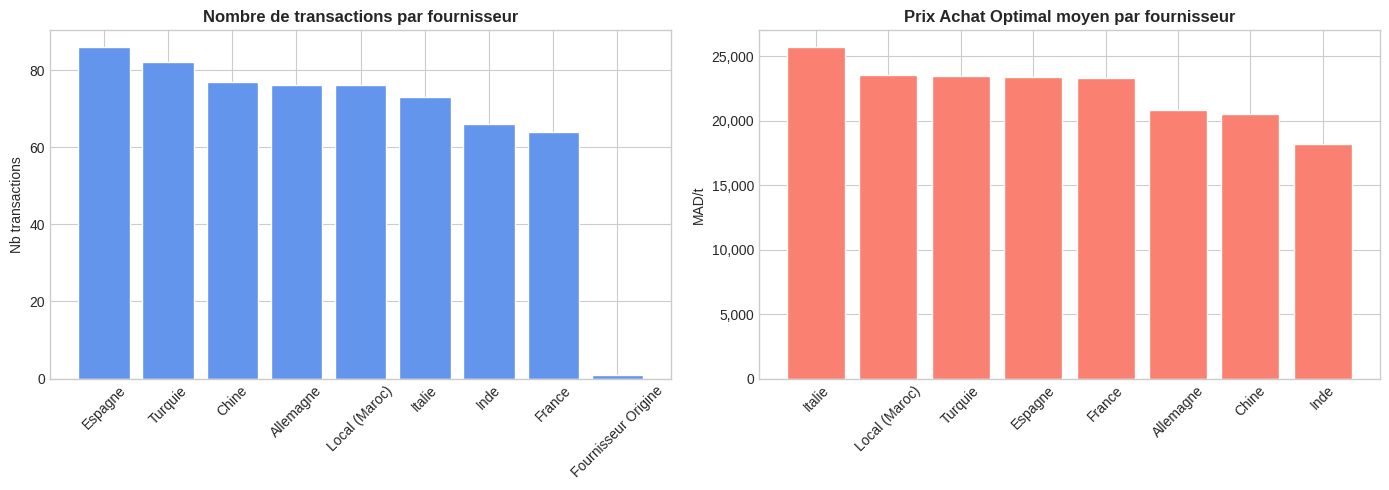

In [22]:
# ── 4.5 Distribution par Fournisseur (Origine) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nb transactions
fourn_count = df['Fournisseur_Origine'].value_counts()
axes[0].bar(fourn_count.index, fourn_count.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Nombre de transactions par fournisseur', fontweight='bold')
axes[0].set_ylabel('Nb transactions')
axes[0].tick_params(axis='x', rotation=45)

# Prix moyen
fourn_prix = df.groupby('Fournisseur_Origine')[TARGET].mean().sort_values(ascending=False)
axes[1].bar(fourn_prix.index, fourn_prix.values, color='salmon', edgecolor='white')
axes[1].set_title('Prix Achat Optimal moyen par fournisseur', fontweight='bold')
axes[1].set_ylabel('MAD/t')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 🛠️ 5. Prétraitement & Feature Engineering

In [27]:
# ── 5.1 Nouvelles features ────────────────────────────────────────────────
df['Ecart_Prix_TCO'] = df[TARGET] - df['TCO_Total_MAD_t']
df['Ratio_Transport_TCO'] = df['Cout_Transport_MAD_t'] / df['TCO_Total_MAD_t']
df['Ratio_Stockage_TCO'] = df['Cout_Stockage_MAD_t'] / df['TCO_Total_MAD_t']
df['Prix_MAD_converti'] = df['Prix_Mondial_USD_t'] * df['Taux_Change_MAD_USD']
df['Fenetre_Favorable'] = (df['Fenetre_Opportunite'] == 'Favorable').astype(int)

print('✅ Features créées :', ['Ecart_Prix_TCO', 'Ratio_Transport_TCO',
      'Ratio_Stockage_TCO', 'Prix_MAD_converti', 'Fenetre_Favorable'])

✅ Features créées : ['Ecart_Prix_TCO', 'Ratio_Transport_TCO', 'Ratio_Stockage_TCO', 'Prix_MAD_converti', 'Fenetre_Favorable']


In [35]:
# ── 5.2 Sélection des features et encodage ────────────────────────────────
CAT_FEATURES = [
    'Matiere_Premiere', 'Saison', 'Region', 'Secteur_Industriel',
    'Fournisseur_Origine', 'Incoterm', 'Mode_Paiement',
    'Certification_Fournisseur', 'Trimestre', 'Strategie_Achat'
]
NUM_FEATURES = [
    'Annee', 'Mois', 'Volume_Commande_t', 'Volatilite_Marche_Pct',
    'Delai_Livraison_j', 'Fiabilite_Fournisseur', 'Risque_Qualite',
    'Score_Fournisseur', 'Prix_Mondial_USD_t', 'Taux_Change_MAD_USD',
    'Prix_Brut_MAD_t', 'Remise_Volume_Pct', 'Prix_Apres_Remise_MAD',
    'Cout_Transport_MAD_t', 'Cout_Stockage_MAD_t', 'Cout_Risque_Qualite_MAD_t',
    'Cout_Financement_MAD_t', 'Cout_Douane_Taxes_MAD_t', 'TCO_Total_MAD_t',
    'IPI', 'Couverture_Prix_Pct',
    'Ratio_Transport_TCO', 'Ratio_Stockage_TCO',
    'Prix_MAD_converti', 'Fenetre_Favorable'
]

X = df[CAT_FEATURES + NUM_FEATURES].copy()
y = df[TARGET].copy()

# Encoder les catégorielles
for col in CAT_FEATURES:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Supprimer les lignes avec des valeurs manquantes dans X ou y
# Après l'encodage des catégories, la colonne `ID_Transaction` peut causer des problèmes.
# On s'assure qu'on ne travaille qu'avec les features et la cible.
combined = pd.concat([X, y], axis=1).dropna()
X = combined.drop(columns=[TARGET])
y = combined[TARGET]

print(f'✅ X shape : {X.shape} | y shape : {y.shape}')

✅ X shape : (600, 35) | y shape : (600,)


In [37]:
# ── 5.3 Split train/test ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Identify and remove constant columns (zero variance) which cause NaNs after StandardScaler
# This needs to be done *before* scaling, as StandardScaler will produce NaNs for such columns
constant_columns = X_train.columns[X_train.std() == 0]
if not constant_columns.empty:
    print(f"⚠️ Dropping constant columns before scaling: {list(constant_columns)}")
    X_train = X_train.drop(columns=constant_columns)
    X_test = X_test.drop(columns=constant_columns)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')


Train : 480 | Test : 120


## 🤖 6. Modélisation Machine Learning

In [29]:
# ── 6.1 Définition des modèles ────────────────────────────────────────────
models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge':               Ridge(alpha=1.0),
    'Lasso':               Lasso(alpha=10.0),
    'Random Forest':       RandomForestRegressor(n_estimators=200, max_depth=12,
                                                  random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200,
                                                      learning_rate=0.05,
                                                      max_depth=5, random_state=SEED),
    'XGBoost':             XGBRegressor(n_estimators=300, learning_rate=0.05,
                                         max_depth=6, subsample=0.8,
                                         colsample_bytree=0.8, random_state=SEED,
                                         verbosity=0),
    'LightGBM':            lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                              num_leaves=63, random_state=SEED,
                                              verbose=-1)
}

print(f'🔄 {len(models)} modèles à entraîner...')


🔄 7 modèles à entraîner...


In [38]:
# ── 6.2 Entraînement et évaluation ───────────────────────────────────────
results = []

for name, model in models.items():
    # Utiliser données scalées pour modèles linéaires
    X_tr = X_train_sc if name in ['Régression Linéaire', 'Ridge', 'Lasso'] else X_train
    X_te = X_test_sc  if name in ['Régression Linéaire', 'Ridge', 'Lasso'] else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds) * 100

    results.append({'Modèle': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape})
    print(f'  ✔ {name:25s}  R²={r2:.4f}  MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape:.2f}%')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print()
results_df.style.background_gradient(subset=['R²'], cmap='Greens') \
                .background_gradient(subset=['MAE', 'RMSE', 'MAPE (%)'], cmap='Reds_r') \
                .format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','R²':'{:.4f}','MAPE (%)':'{:.2f}%'})

  ✔ Régression Linéaire        R²=0.9987  MAE=562  RMSE=845  MAPE=4.05%
  ✔ Ridge                      R²=0.9985  MAE=589  RMSE=901  MAPE=4.96%
  ✔ Lasso                      R²=0.9985  MAE=593  RMSE=907  MAPE=5.33%
  ✔ Random Forest              R²=0.9978  MAE=598  RMSE=1,091  MAPE=2.52%
  ✔ Gradient Boosting          R²=0.9978  MAE=605  RMSE=1,104  MAPE=2.50%
  ✔ XGBoost                    R²=0.9977  MAE=627  RMSE=1,114  MAPE=2.64%
  ✔ LightGBM                   R²=0.9977  MAE=633  RMSE=1,120  MAPE=2.91%



,Modèle,MAE,RMSE,R²,MAPE (%)
0,Régression Linéaire,562,845,0.9987,4.05%
1,Ridge,589,901,0.9985,4.96%
2,Lasso,593,907,0.9985,5.33%
3,Random Forest,598,"1,091",0.9978,2.52%
4,Gradient Boosting,605,"1,104",0.9978,2.50%
5,XGBoost,627,"1,114",0.9977,2.64%
6,LightGBM,633,"1,120",0.9977,2.91%


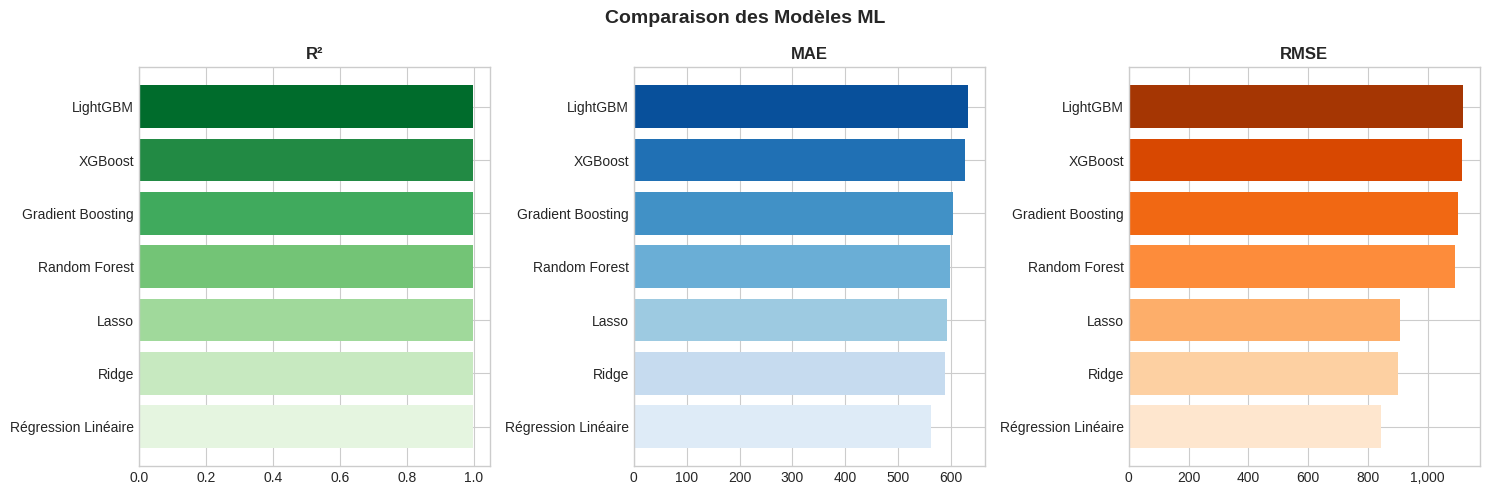

In [39]:
# ── 6.3 Comparaison visuelle des modèles ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des Modèles ML', fontsize=14, fontweight='bold')

metrics = [('R²', 'Greens'), ('MAE', 'Blues'), ('RMSE', 'Oranges')]
for ax, (metric, cmap) in zip(axes, metrics):
    data = results_df.sort_values(metric, ascending=(metric != 'R²'))
    colors = sns.color_palette(cmap, len(data))
    ax.barh(data['Modèle'], data[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    if metric in ['MAE', 'RMSE']:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 📈 7. Évaluation & Interprétabilité du Meilleur Modèle

In [40]:
# ── 7.1 Meilleur modèle ──────────────────────────────────────────────────
best_name = results_df.iloc[0]['Modèle']
best_model = models[best_name]
X_te = X_test_sc if best_name in ['Régression Linéaire', 'Ridge', 'Lasso'] else X_test
best_preds = best_model.predict(X_te)

print(f'🏆 Meilleur modèle : {best_name}')
print(f'   R²   = {r2_score(y_test, best_preds):.4f}')
print(f'   MAE  = {mean_absolute_error(y_test, best_preds):,.0f} MAD/t')
print(f'   RMSE = {np.sqrt(mean_squared_error(y_test, best_preds)):,.0f} MAD/t')
print(f'   MAPE = {mean_absolute_percentage_error(y_test, best_preds)*100:.2f}%')

🏆 Meilleur modèle : Régression Linéaire
   R²   = 0.9987
   MAE  = 562 MAD/t
   RMSE = 845 MAD/t
   MAPE = 4.05%


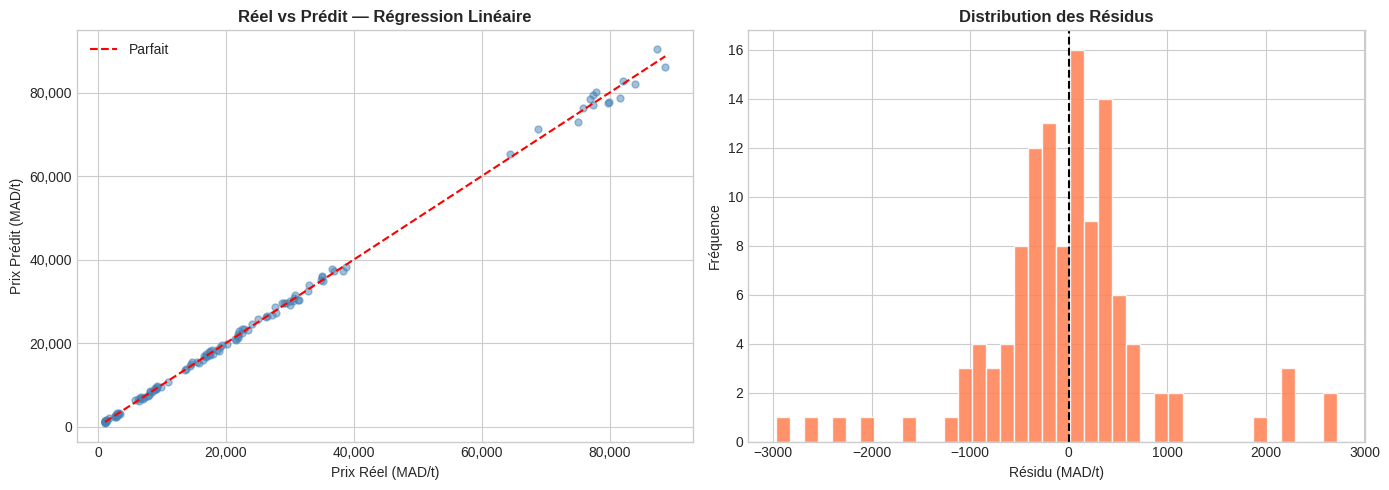

In [41]:
# ── 7.2 Réel vs Prédit ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, best_preds, alpha=0.5, color='steelblue', s=25)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Parfait')
axes[0].set_title(f'Réel vs Prédit — {best_name}', fontweight='bold')
axes[0].set_xlabel('Prix Réel (MAD/t)')
axes[0].set_ylabel('Prix Prédit (MAD/t)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# Résidus
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribution des Résidus', fontweight='bold')
axes[1].set_xlabel('Résidu (MAD/t)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

In [42]:
# ── 7.3 Importance des Features (tree-based) ─────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_,
                             index=CAT_FEATURES + NUM_FEATURES)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = sns.color_palette('viridis', len(top20))
    ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
    ax.set_title(f'Top 20 Features — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️ Importance des features non disponible pour ce modèle.')

ℹ️ Importance des features non disponible pour ce modèle.


📊 SHAP Summary Plot (top 15 features):


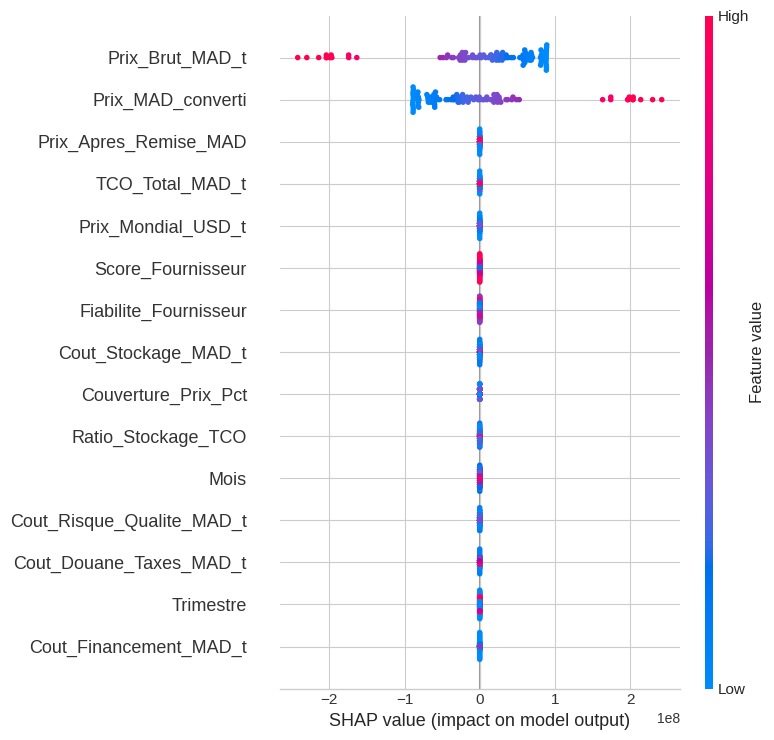

In [44]:
# ── 7.4 Analyse SHAP ─────────────────────────────────────────────────────
try:
    # Determine the appropriate explainer based on model type
    if isinstance(best_model, (RandomForestRegressor, GradientBoostingRegressor, XGBRegressor, lgb.LGBMRegressor)):
        explainer = shap.TreeExplainer(best_model)
    elif isinstance(best_model, (LinearRegression, Ridge, Lasso)):
        # For linear models, the input to LinearExplainer should be scaled data if the model was trained on scaled data
        # We need the original X_test columns names for feature names
        if best_name in ['Régression Linéaire', 'Ridge', 'Lasso']:
            explainer = shap.LinearExplainer(best_model, X_test_sc, feature_perturbation="interventional")
            shap_values = explainer.shap_values(X_test_sc[:100]) # Use scaled test data for prediction
        else:
            explainer = shap.LinearExplainer(best_model, X_test, feature_perturbation="interventional")
            shap_values = explainer.shap_values(X_test[:100]) # Use unscaled test data for prediction
    else:
        raise ValueError("Model type not supported for SHAP explanation")

    # Generate shap values if not already generated for LinearExplainer
    if not 'shap_values' in locals():
        shap_values = explainer.shap_values(X_te[:100])  # Use X_te as it's already selected as scaled/unscaled appropriately

    print('📊 SHAP Summary Plot (top 15 features):')
    # For linear models with LinearExplainer, shap_values is an array, not a list of arrays
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0] if len(shap_values) > 0 else shap_values, X_te[:100] if best_name in ['Régression Linéaire', 'Ridge', 'Lasso'] else X_test[:100],
                          feature_names=X_test.columns.tolist(),
                          max_display=15, show=True)
    else:
        shap.summary_plot(shap_values, X_te[:100] if best_name in ['Régression Linéaire', 'Ridge', 'Lasso'] else X_test[:100],
                          feature_names=X_test.columns.tolist(),
                          max_display=15, show=True)

except Exception as e:
    print(f'ℹ️ SHAP non disponible pour ce modèle : {e}')

📊 Validation Croisée 5-Fold — Régression Linéaire
   R²  : 0.9987 ± 0.0002
   MAE : 514 ± 59 MAD/t


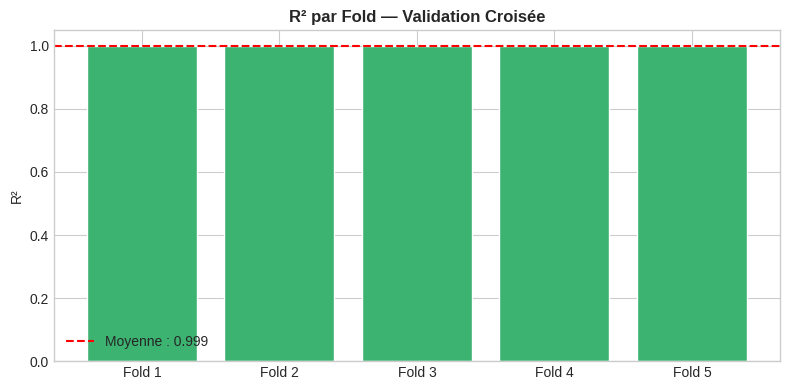

In [45]:
# ── 7.5 Validation croisée (K=5) ─────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2   = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
cv_mae  = -cross_val_score(best_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print(f'📊 Validation Croisée 5-Fold — {best_name}')
print(f'   R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'   MAE : {cv_mae.mean():,.0f} ± {cv_mae.std():,.0f} MAD/t')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_r2, color='mediumseagreen', edgecolor='white')
ax.axhline(cv_r2.mean(), color='red', linestyle='--', label=f'Moyenne : {cv_r2.mean():.3f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title(f'R² par Fold — Validation Croisée', fontweight='bold')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

## 💾 8. Export des Résultats

In [46]:
# Ajouter les prédictions au jeu de test
test_results = X_test.copy()
test_results['Prix_Reel_MAD_t']  = y_test.values
test_results['Prix_Predit_MAD_t'] = best_preds
test_results['Residu_MAD_t']     = y_test.values - best_preds
test_results['Erreur_Pct']       = np.abs(test_results['Residu_MAD_t'] / test_results['Prix_Reel_MAD_t']) * 100

# Export CSV
test_results.to_csv('predictions_prix_optimal.csv', index=False)

# Export comparatif des modèles
results_df.to_csv('comparaison_modeles.csv', index=False)

# Téléchargement automatique
from google.colab import files
files.download('predictions_prix_optimal.csv')
files.download('comparaison_modeles.csv')

print('✅ Fichiers exportés !')
print()
print('── RÉSUMÉ FINAL ────────────────────────────────────────────')
print(f'  Meilleur modèle  : {best_name}')
print(f'  R²               : {r2_score(y_test, best_preds):.4f}')
print(f'  MAE              : {mean_absolute_error(y_test, best_preds):,.0f} MAD/t')
print(f'  MAPE             : {mean_absolute_percentage_error(y_test, best_preds)*100:.2f}%')
print('────────────────────────────────────────────────────────────')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fichiers exportés !

── RÉSUMÉ FINAL ────────────────────────────────────────────
  Meilleur modèle  : Régression Linéaire
  R²               : 0.9987
  MAE              : 562 MAD/t
  MAPE             : 4.05%
────────────────────────────────────────────────────────────
